# Adobe Leadership Agent Demo

I use this notebook as the fastest review path for the assignment.

What I can do from here:

1. Set `OPENAI_API_KEY`, model names, and parser choice in one place.
2. Rebuild ingestion and indexes if I want a fresh run.
3. Ask a single natural-language leadership question without using the CLI.
4. Show the markdown answer directly in the notebook and save the JSON report under `outputs/sample_answers/`.

Notes:

- The preview section below shows the latest saved checked answers.
- If I run the last cell, it generates a fresh answer, so wording can differ slightly from the preview.
- If I want the fresh run to match the preview as closely as possible, I should keep `PARSER_PRIMARY` and `PARSER_FALLBACK` both set to `docling` and use deterministic mode by leaving `OPENAI_API_KEY` blank.


## Latest Checked Outputs

I am showing the latest saved answers here so the main outcomes are visible immediately when this notebook opens.

These lines are copied from the current JSON reports in `outputs/sample_answers/` using the `docling` parser path.

- `What is our current revenue trend?`  
  `Revenue shows an upward trend from Q1FY24 (5,182) to Q2FY25 (5,873), a change of 13.3%.`

- `Which departments are underperforming?`  
  `Digital Experience appears to be underperforming relative to Digital Media, with 4.3% change from Q4FY24 to Q2FY25 versus 4.8%.`

- `What were the key risks highlighted in the last quarter?`  
  `In the most recent quarter materials, the key risks highlighted were primarily forward-looking business and operational risks: failure to innovate and meet customer needs; issues related to AI development and use; failure to compete effectively; reputational/brand damage; inability to realize benefits from investments or acquisitions; IT service interruptions or failures (including third-party systems); security incidents; weak third-party business relationships; adverse macroeconomic conditions and multinational exposure; and complex sales cycles. The materials also flagged additional risks such as recruiting/retaining key personnel, litigation/regulatory/IP claims, compliance with global laws and privacy/security rules, foreign exchange fluctuations, revenue-recognition timing, debt obligations, and stock-price volatility.`

The corresponding files are:

- `outputs/sample_answers/docling_what_is_our_current_revenue_trend.json`
- `outputs/sample_answers/docling_which_departments_are_underperforming.json`
- `outputs/sample_answers/docling_what_were_the_key_risks_highlighted_in_the_last_quarter.json`

Validation notes:

- These files were regenerated from a fresh `docling` parse with FAISS-backed indexes.
- OpenAI was used for classification/synthesis, while computed quantitative answers are kept deterministic when they are stronger than narrative paraphrasing.
- I also checked the same three questions across other parser paths earlier in the workflow.


In [8]:
from pathlib import Path
import json

from IPython.display import Markdown, display

from leadership_agent.answering import LeadershipAgent, render_report, save_report
from leadership_agent.config import AppConfig
from leadership_agent.utils import slugify

PROJECT_ROOT = Path.cwd()
CONFIG_PATH = PROJECT_ROOT / "config.yaml"

print(f"Project root: {PROJECT_ROOT}")
print(f"Config path: {CONFIG_PATH}")


Project root: d:\Preetam\preets\adobe\adobe_assignment
Config path: d:\Preetam\preets\adobe\adobe_assignment\config.yaml


In [ ]:
# Edit these values if you want to test with your own key or model choices.
# Leave OPENAI_API_KEY blank to use the deterministic offline path.

OPENAI_API_KEY = ""
OPENAI_NANO_MODEL = "gpt-5.4-nano"
OPENAI_MINI_MODEL = "gpt-5.4-mini"
EMBEDDING_MODEL = "BAAI/bge-small-en-v1.5"

PARSER_PRIMARY = "docling"
PARSER_FALLBACK = "docling"

FORCE_REBUILD = True
QUESTION = "What is the trend in Digital Media ARR over the last few quarters?"
REPORT_FILENAME = None  # Example: "review_answer.json"

SAMPLE_QUESTIONS = [
    "What is our current revenue trend?",
    "Which departments are underperforming?",
    "What were the key risks highlighted in the last quarter?",
]

SAMPLE_QUESTIONS


['What is our current revenue trend?',
 'Which departments are underperforming?',
 'What were the key risks highlighted in the last quarter?']

In [10]:
def build_notebook_config() -> AppConfig:
    config = AppConfig.load(CONFIG_PATH)
    config.models.nano = OPENAI_NANO_MODEL.strip() or config.models.nano
    config.models.mini = OPENAI_MINI_MODEL.strip() or config.models.mini
    config.models.embedding = EMBEDDING_MODEL.strip() or config.models.embedding
    config.parser.primary = PARSER_PRIMARY.strip() or config.parser.primary
    config.parser.fallback = PARSER_FALLBACK.strip() or config.parser.fallback
    if OPENAI_API_KEY.strip():
        config.runtime.llm_provider = "openai"
        config.runtime.openai_api_key = OPENAI_API_KEY.strip()
    else:
        config.runtime.llm_provider = "extractive"
        config.runtime.openai_api_key = ""
    return config


def parsed_ready(config: AppConfig) -> bool:
    required = [
        config.parsed_data_dir / "sections" / "sections.jsonl",
        config.parsed_data_dir / "chunks" / "chunks.jsonl",
        config.parsed_data_dir / "tables" / "tables.jsonl",
    ]
    return all(path.exists() for path in required)


def indexes_ready(config: AppConfig) -> bool:
    required = [
        config.index_dir / "bm25" / "sections.pkl",
        config.index_dir / "bm25" / "chunks.pkl",
        config.index_dir / "dense" / "sections.meta.json",
        config.index_dir / "metadata" / "leadership.duckdb",
    ]
    return all(path.exists() for path in required)


def prepare_pipeline(config: AppConfig, force_rebuild: bool = False):
    agent = LeadershipAgent(config)
    status = {}
    if force_rebuild or not parsed_ready(config):
        status["ingest"] = agent.ingest()
    else:
        status["ingest"] = "skipped"
    if force_rebuild or not indexes_ready(config):
        status["build_index"] = agent.build_index()
    else:
        status["build_index"] = "skipped"
    return agent, status


def ask_notebook_question(question: str, report_filename: str | None = None, force_rebuild: bool = False):
    config = build_notebook_config()
    agent, prep_status = prepare_pipeline(config, force_rebuild=force_rebuild)
    report = agent.ask(question, output_dir=config.output_dir)

    filename = (report_filename or f"{slugify(question)}.json").strip()
    if not filename.lower().endswith(".json"):
        filename += ".json"
    report_path = config.output_dir / "sample_answers" / filename
    save_report(report, report_path)

    summary = {
        "question": question,
        "llm_provider": config.runtime.llm_provider,
        "nano_model": config.models.nano,
        "mini_model": config.models.mini,
        "embedding_model": config.models.embedding,
        "parser_primary": config.parser.primary,
        "parser_fallback": config.parser.fallback,
        "report_path": str(report_path),
    }

    print("Run summary:")
    print(json.dumps(summary, indent=2))
    print("\nPreparation status:")
    print(json.dumps(prep_status, indent=2))
    print("\nRendered answer:\n")
    display(Markdown(render_report(report)))
    return report, report_path, prep_status


In [11]:
report, report_path, prep_status = ask_notebook_question(
    question=QUESTION,
    report_filename=REPORT_FILENAME,
    force_rebuild=FORCE_REBUILD,
)

report_path


2026-03-23 20:15:35,973 INFO docling.datamodel.document | detected formats: [<InputFormat.PDF: 'pdf'>]
2026-03-23 20:15:35,998 INFO docling.document_converter | Going to convert document batch...
2026-03-23 20:15:35,998 INFO docling.document_converter | Initializing pipeline for StandardPdfPipeline with options hash a6a2eef09bfdbd6bdaeaf15fcaebde59
2026-03-23 20:15:35,998 INFO docling.utils.accelerator_utils | Accelerator device: 'cuda:0'
[INFO] 2026-03-23 20:15:36,027 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-03-23 20:15:36,034 [RapidOCR] download_file.py:60: File exists and is valid: D:\Preetam\preets\adobe\adobe_assignment\.venv\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_infer.onnx
[INFO] 2026-03-23 20:15:36,035 [RapidOCR] main.py:53: Using D:\Preetam\preets\adobe\adobe_assignment\.venv\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_infer.onnx
[INFO] 2026-03-23 20:15:36,244 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-03-23 20:1

Run summary:
{
  "question": "What is the trend in Digital Media ARR over the last few quarters?",
  "llm_provider": "openai",
  "nano_model": "gpt-5.4-nano",
  "mini_model": "gpt-5.4-mini",
  "embedding_model": "BAAI/bge-small-en-v1.5",
  "parser_primary": "docling",
  "parser_fallback": "docling",
  "report_path": "outputs\\sample_answers\\what_is_the_trend_in_digital_media_arr_over_the_last_few_quarters.json"
}

Preparation status:
{
  "ingest": {
    "documents": 3,
    "sections": 322,
    "chunks": 347,
    "tables": 84,
    "source_dir": "data\\raw",
    "parser_chain": [
      "docling",
      "native"
    ]
  },
  "build_index": {
    "documents": 3,
    "sections": 322,
    "chunks": 347,
    "tables": 84,
    "dense": {
      "sections": {
        "backend": "fastembed",
        "model": "BAAI/bge-small-en-v1.5",
        "count": 322,
        "usage": {
          "model": "BAAI/bge-small-en-v1.5",
          "errors": []
        }
      },
      "chunks": {
        "backend":

## Direct Answer
Digital Media ARR has been trending upward over the last few quarters. The clearest reported points show it rising from $17.33 billion at the end of fiscal 2024 to $18.09 billion exiting Q2 FY2025, with the annual report also noting a revalued FY2024 ending ARR of $17.22 billion under FY2025 currency rates. That indicates continued quarter-to-quarter growth, though the exact intermediate quarterly ARR values are not provided in the supplied evidence.

## Key Evidence
- FY2024 Digital Media ARR ended at $17.33 billion, up from $15.33 billion at the end of FY2023.
- Adobe reported Digital Media ARR exiting Q2 FY2025 was $18.09 billion, representing 12.1% year-over-year growth.
- The FY2024 annual report notes that revalued FY2024 ending Digital Media ARR would have been $17.22 billion under FY2025 currency rates.

## Sources
- adobe_q2_fy2025_earnings_release.pdf | Second Quarter Fiscal Year 2025 Business Segment Highlights | pages 1-1
- adobe_fy2024_annual_report.pdf | | Digital Media ARR | Creative ARR + Document Cloud ARR | | pages 45-101

## Caveats
- The supplied evidence does not include a full quarter-by-quarter ARR series for the last few quarters, so the precise QoQ magnitude cannot be calculated from the provided materials.
- ARR is currency-rate adjusted for measurement purposes, so comparisons across fiscal years may be affected by revaluation methodology.
- The provided evidence supports that Digital Media ARR increased from $15.33B (end of FY2023) to $17.33B (end of FY2024) and that ARR exiting Q2 FY2025 was $18.09B, but it does not provide “last few quarters” intermediate quarter-end ARR values (e.g., Q3 FY2024, Q4 FY2024, Q1 FY2025).
- The answer claims “continued quarter-to-quarter growth” and references “clearest reported points” as if they establish a multi-quarter trend; however, the evidence only gives two quarter-end points (end of FY2024 and exiting Q2 FY2025) plus annual FY2024 revaluation context, not a sequence of consecutive quarters.

WindowsPath('outputs/sample_answers/what_is_the_trend_in_digital_media_arr_over_the_last_few_quarters.json')

## Validation: LLM as a Judge

I use this section to run a broader validation pass across 10 grounded questions from the Adobe PDFs.

For each answer, I ask an LLM judge to score the output against a small rubric. Each metric gets a numeric score from `1` to `5`, and I also map that score to a label:

- `1-2` = `Low`
- `3` = `Medium`
- `4-5` = `High`

Judge metrics:

- `Relevance`: Does the answer directly address the question?
- `Groundedness`: Are the claims supported by the evidence and caveats?
- `Completeness`: Does the answer cover the requested scope?
- `Citation Quality`: Are the cited sources specific and useful?
- `Numerical Consistency`: Are numbers, trends, and calculations internally consistent?
- `Clarity`: Is the answer easy to understand?

This gives me a lightweight review layer for factual quality, not just a demo answer.


In [12]:
VALIDATION_QUESTIONS = [
    "What is our current revenue trend?",
    "Which departments are underperforming?",
    "What were the key risks highlighted in the last quarter?",
    "What is the trend in Digital Media ARR over the last few quarters?",
    "What is Adobe's current revenue mix by geography?",
    "Which business segment contributes the largest share of total revenue?",
    "How have diluted shares outstanding changed over the last six quarters?",
    "What are Adobe's Q3 FY2025 revenue targets?",
    "What was Adobe's total revenue growth from FY2023 to FY2024?",
]

JUDGE_METRICS = {
    "relevance": "Does the answer directly address the question asked?",
    "groundedness": "Are the claims supported by cited evidence and caveats?",
    "completeness": "Does the answer cover the main requested scope without major omissions?",
    "citation_quality": "Are the cited sources specific and appropriate for the answer?",
    "numerical_consistency": "Are the numbers, trends, and calculations internally consistent?",
    "clarity": "Is the answer clear and easy to follow?",
}

VALIDATION_FORCE_REBUILD = False
VALIDATION_OUTPUT_FILENAME = None  # Example: "validation_llm_judge_docling.json"

VALIDATION_QUESTIONS


['What is our current revenue trend?',
 'Which departments are underperforming?',
 'What were the key risks highlighted in the last quarter?',
 'What is the trend in Digital Media ARR over the last few quarters?',
 "What is Adobe's current revenue mix by geography?",
 'Which business segment contributes the largest share of total revenue?',
 'How have diluted shares outstanding changed over the last six quarters?',
 "What are Adobe's Q3 FY2025 revenue targets?",
 "What was Adobe's total revenue growth from FY2023 to FY2024?"]

In [13]:
from statistics import mean

import matplotlib.pyplot as plt
from leadership_agent.utils import openai_json_completion


def score_band(score: int | float) -> str:
    if score <= 2:
        return "Low"
    if score < 4:
        return "Medium"
    return "High"


def build_validation_output_path(config: AppConfig, output_filename: str | None = None) -> Path:
    parser_name = slugify(config.parser.primary or "parser")
    filename = (output_filename or f"validation_llm_judge_{parser_name}.json").strip()
    if not filename.lower().endswith(".json"):
        filename += ".json"
    return config.output_dir / "sample_answers" / filename


def judge_answer_with_llm(question: str, report, config: AppConfig) -> tuple[dict, dict]:
    if not OPENAI_API_KEY.strip():
        raise ValueError("OPENAI_API_KEY is required to run the LLM-as-a-judge validation section.")

    metric_schema = {
        "type": "object",
        "additionalProperties": False,
        "properties": {
            "score": {"type": "integer", "minimum": 1, "maximum": 5},
            "reason": {"type": "string"},
        },
        "required": ["score", "reason"],
    }
    schema = {
        "type": "object",
        "additionalProperties": False,
        "properties": {
            "relevance": metric_schema,
            "groundedness": metric_schema,
            "completeness": metric_schema,
            "citation_quality": metric_schema,
            "numerical_consistency": metric_schema,
            "clarity": metric_schema,
            "overall_summary": {"type": "string"},
        },
        "required": [
            "relevance",
            "groundedness",
            "completeness",
            "citation_quality",
            "numerical_consistency",
            "clarity",
            "overall_summary",
        ],
    }

    compact_report = {
        "question": report.question,
        "question_class": report.question_class,
        "direct_answer": report.direct_answer,
        "key_evidence": report.key_evidence,
        "sources": [source.to_dict() for source in report.sources],
        "caveats": report.caveats,
        "evidence_pack": report.evidence_pack[:4],
        "computed": {
            "trend_summary": report.analytics.get("computed", {}).get("trend_summary"),
            "metric_series": (report.analytics.get("computed", {}).get("metric_series") or [])[:8],
            "comparison_rows": (report.analytics.get("computed", {}).get("comparison_rows") or [])[:4],
            "risk_factors": (report.analytics.get("computed", {}).get("risk_factors") or [])[:8],
        },
    }

    system_prompt = (
        "You are a strict evaluation judge for a document intelligence system. "
        "Score the answer only from the provided question, answer, evidence, sources, and caveats. "
        "Be conservative and penalize unsupported claims, weak citations, or incomplete coverage."
    )
    user_prompt = (
        f"Question: {question}\n\n"
        f"Rubric: {json.dumps(JUDGE_METRICS, ensure_ascii=False)}\n\n"
        f"Answer payload: {json.dumps(compact_report, ensure_ascii=False)}\n\n"
        "Return scores from 1 to 5 for each metric. Use 1 for very poor and 5 for excellent. "
        "Groundedness should focus on whether the claims are actually supported by the supplied evidence. "
        "Numerical consistency should focus on whether the answer's numbers and comparisons are internally coherent."
    )

    parsed, usage = openai_json_completion(
        config.runtime,
        config.mini_model_candidates(),
        system_prompt,
        user_prompt,
        "llm_judge_validation",
        schema,
    )
    if parsed is None:
        raise RuntimeError(f"LLM judge failed: {usage}")

    metric_results = {}
    for metric_name in JUDGE_METRICS:
        metric_payload = parsed[metric_name]
        score = int(metric_payload["score"])
        metric_results[metric_name] = {
            "score": score,
            "band": score_band(score),
            "reason": metric_payload["reason"],
        }

    overall_score = round(mean(item["score"] for item in metric_results.values()), 2)
    result = {
        "question": question,
        "question_class": report.question_class,
        "direct_answer": report.direct_answer,
        "metrics": metric_results,
        "overall_score": overall_score,
        "overall_band": score_band(overall_score),
        "overall_summary": parsed["overall_summary"],
    }
    return result, usage


def render_validation_summary_table(results: list[dict]) -> str:
    headers = [
        "Question",
        "Overall",
        "Relevance",
        "Grounded",
        "Complete",
        "Citations",
        "Numeric",
        "Clarity",
    ]
    lines = [
        "## Validation Results",
        "",
        "| " + " | ".join(headers) + " |",
        "|" + "|".join(["---"] * len(headers)) + "|",
    ]
    for item in results:
        metrics = item["metrics"]
        row = [
            item["question"],
            f"{item['overall_score']} ({item['overall_band']})",
            f"{metrics['relevance']['score']} ({metrics['relevance']['band']})",
            f"{metrics['groundedness']['score']} ({metrics['groundedness']['band']})",
            f"{metrics['completeness']['score']} ({metrics['completeness']['band']})",
            f"{metrics['citation_quality']['score']} ({metrics['citation_quality']['band']})",
            f"{metrics['numerical_consistency']['score']} ({metrics['numerical_consistency']['band']})",
            f"{metrics['clarity']['score']} ({metrics['clarity']['band']})",
        ]
        lines.append("| " + " | ".join(str(value).replace("|", "/") for value in row) + " |")
    return "\n".join(lines)


def render_validation_notes(results: list[dict]) -> str:
    lines = ["## Judge Notes", ""]
    for item in results:
        lines.append(f"### {item['question']}")
        lines.append(f"- Overall: {item['overall_score']} ({item['overall_band']})")
        lines.append(f"- Summary: {item['overall_summary']}")
        for metric_name, metric_label in JUDGE_METRICS.items():
            metric = item["metrics"][metric_name]
            lines.append(
                f"- {metric_label}: {metric['score']} ({metric['band']}) - {metric['reason']}"
            )
        lines.append("")
    return "\n".join(lines)


def plot_validation_overview(results: list[dict]):
    metric_names = list(JUDGE_METRICS.keys())
    metric_labels = [
        "Relevance",
        "Groundedness",
        "Completeness",
        "Citation Quality",
        "Numerical Consistency",
        "Clarity",
    ]
    avg_scores = [
        round(mean(item["metrics"][metric]["score"] for item in results), 2)
        for metric in metric_names
    ]

    band_counts = {"Low": 0, "Medium": 0, "High": 0}
    for item in results:
        band_counts[item["overall_band"]] = band_counts.get(item["overall_band"], 0) + 1

    overall_average = round(mean(item["overall_score"] for item in results), 2)
    parser_name = build_notebook_config().parser.primary

    plt.style.use("seaborn-v0_8-whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), gridspec_kw={"width_ratios": [1.5, 1]})
    fig.patch.set_facecolor("#fcfbf7")

    metric_colors = ["#1f4e5f", "#33658a", "#86bbd8", "#758e4f", "#f6ae2d", "#bc6c25"]
    bars = axes[0].bar(metric_labels, avg_scores, color=metric_colors, width=0.68, edgecolor="#17324d", linewidth=0.4)
    axes[0].set_ylim(0, 5)
    axes[0].axhspan(4, 5, color="#d8f3dc", alpha=0.65)
    axes[0].axhspan(3, 4, color="#fff3bf", alpha=0.55)
    axes[0].axhspan(0, 2, color="#f8d7da", alpha=0.4)
    axes[0].set_title("Average Judge Scores by Metric", fontsize=13, weight="bold")
    axes[0].set_ylabel("Score (1-5)")
    axes[0].tick_params(axis="x", rotation=25, labelsize=10)
    axes[0].tick_params(axis="y", labelsize=10)
    axes[0].spines[["top", "right"]].set_visible(False)
    for bar, score in zip(bars, avg_scores):
        axes[0].text(bar.get_x() + bar.get_width() / 2, score + 0.08, f"{score}", ha="center", va="bottom", fontsize=10, weight="bold")

    labels = ["Low", "Medium", "High"]
    sizes = [band_counts[label] for label in labels]
    colors = ["#d1495b", "#edae49", "#2a9d8f"]
    explode = [0.02 if count else 0 for count in sizes]
    wedges, texts, autotexts = axes[1].pie(
        sizes,
        labels=labels,
        autopct=lambda pct: f"{pct:.0f}%" if pct > 0 else "",
        startangle=90,
        colors=colors,
        explode=explode,
        wedgeprops={"width": 0.42, "edgecolor": "white", "linewidth": 2},
        textprops={"fontsize": 10, "weight": "bold"},
    )
    for label, count, autotext in zip(labels, sizes, autotexts):
        if count > 0:
            autotext.set_text(f"{count}")
            autotext.set_color("white")
    axes[1].set_title("Overall Answer Quality Distribution", fontsize=13, weight="bold")

    fig.suptitle(
        f"Validation Overview | Parser: {parser_name} | Overall Average: {overall_average}/5",
        fontsize=15,
        weight="bold",
        color="#17324d",
    )
    fig.text(0.5, 0.01, "This is an aggregate view across the full validation set, not a per-question chart.", ha="center", fontsize=10, color="#4f5d75")
    plt.tight_layout(rect=[0, 0.04, 1, 0.93])
    plt.show()


def run_llm_judge_validation(force_rebuild: bool = False, output_filename: str | None = None):
    config = build_notebook_config()
    if config.runtime.llm_provider != "openai" or not config.runtime.openai_api_key:
        raise ValueError("Set OPENAI_API_KEY in the settings cell before running the LLM-as-a-judge validation section.")

    agent, prep_status = prepare_pipeline(config, force_rebuild=force_rebuild)
    results = []
    judge_usage = []

    for index, question in enumerate(VALIDATION_QUESTIONS, start=1):
        print(f"[{index}/{len(VALIDATION_QUESTIONS)}] Answering and judging: {question}")
        report = agent.ask(question, output_dir=config.output_dir)
        result, usage = judge_answer_with_llm(question, report, config)
        results.append(result)
        judge_usage.append({"question": question, "usage": usage})

    output_path = build_validation_output_path(config, output_filename=output_filename)
    payload = {
        "parser_primary": config.parser.primary,
        "parser_fallback": config.parser.fallback,
        "questions": VALIDATION_QUESTIONS,
        "metric_rubric": JUDGE_METRICS,
        "score_bands": {"Low": "1-2", "Medium": "3", "High": "4-5"},
        "results": results,
        "judge_usage": judge_usage,
        "prep_status": prep_status,
    }
    output_path.write_text(json.dumps(payload, indent=2, ensure_ascii=False), encoding="utf-8")
    return results, output_path, prep_status


[1/9] Answering and judging: What is our current revenue trend?


2026-03-23 20:18:07,916 INFO httpx | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-23 20:18:12,739 INFO httpx | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-23 20:18:15,495 INFO httpx | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-23 20:18:19,149 INFO httpx | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[2/9] Answering and judging: Which departments are underperforming?


2026-03-23 20:18:21,388 INFO httpx | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-23 20:18:26,119 INFO httpx | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-23 20:18:29,543 INFO httpx | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-23 20:18:33,119 INFO httpx | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[3/9] Answering and judging: What were the key risks highlighted in the last quarter?


...

[8/9] Answering and judging: What are Adobe's Q3 FY2025 revenue targets?


2026-03-23 20:19:53,697 INFO httpx | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-23 20:19:57,511 INFO httpx | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-23 20:19:59,106 INFO httpx | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-23 20:20:02,106 INFO httpx | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[9/9] Answering and judging: What was Adobe's total revenue growth from FY2023 to FY2024?


2026-03-23 20:20:03,963 INFO httpx | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-23 20:20:08,370 INFO httpx | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-23 20:20:10,605 INFO httpx | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-23 20:20:13,840 INFO httpx | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


## Validation Results

| Question | Overall | Relevance | Grounded | Complete | Citations | Numeric | Clarity |
|---|---|---|---|---|---|---|---|
| What is our current revenue trend? | 3.17 (Medium) | 5 (High) | 2 (Low) | 3 (Medium) | 2 (Low) | 3 (Medium) | 4 (High) |
| Which departments are underperforming? | 2.83 (Medium) | 2 (Low) | 2 (Low) | 2 (Low) | 3 (Medium) | 4 (High) | 4 (High) |
| What were the key risks highlighted in the last quarter? | 3.33 (Medium) | 4 (High) | 2 (Low) | 3 (Medium) | 2 (Low) | 5 (High) | 4 (High) |
| What is the trend in Digital Media ARR over the last few quarters? | 3.17 (Medium) | 4 (High) | 2 (Low) | 3 (Medium) | 2 (Low) | 4 (High) | 4 (High) |
| What is Adobe's current revenue mix by geography? | 4.17 (High) | 4 (High) | 5 (High) | 2 (Low) | 4 (High) | 5 (High) | 5 (High) |
| Which business segment contributes the largest share of total revenue? | 3 (Medium) | 4 (High) | 2 (Low) | 2 (Low) | 2 (Low) | 4 (High) | 4 (High) |
| How have diluted shares outstanding changed over the last six quarters? | 4.67 (High) | 5 (High) | 5 (High) | 4 (High) | 4 (High) | 5 (High) | 5 (High) |
| What are Adobe's Q3 FY2025 revenue targets? | 4.83 (High) | 5 (High) | 5 (High) | 4 (High) | 5 (High) | 5 (High) | 5 (High) |
| What was Adobe's total revenue growth from FY2023 to FY2024? | 1.67 (Low) | 2 (Low) | 1 (Low) | 2 (Low) | 1 (Low) | 1 (Low) | 3 (Medium) |

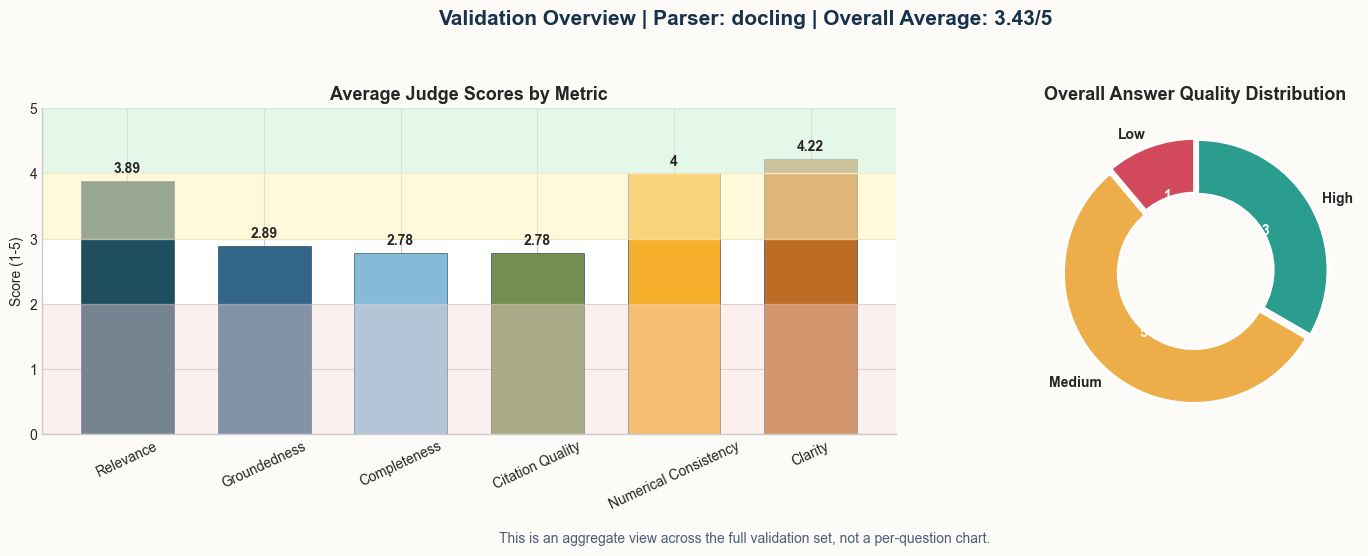

## Judge Notes

### What is our current revenue trend?
- Overall: 3.17 (Medium)
- Summary: The response is clear and relevant, but its numeric trend claim is only partially grounded in the provided evidence. The overall upward direction is reasonable, yet the specific quarter series and computed percentage are not fully substantiated by the cited sources.
- Does the answer directly address the question asked?: 5 (High) - The answer directly addresses the question by summarizing the current revenue trend.
- Are the claims supported by cited evidence and caveats?: 2 (Low) - The conclusion of an upward trend is plausible, but the specific quarter-by-quarter figures and the 13.3% change are not fully supported by the supplied evidence. The caveats explicitly note that several cited numbers are not present in the evidence pack and that the sequential comparison is not substantiated.
- Does the answer cover the main requested scope without major omissions?: 3 (Medium) - It provides a concise trend direction and an overall change, but omits context such as whether the trend is sequential, year-over-year, or both, and does not explain the basis for the calculation beyond the raw series.
- Are the cited sources specific and appropriate for the answer?: 2 (Low) - The cited sources are broadly relevant Adobe documents, but the answer relies on evidence not actually shown in the provided excerpts. The citations are therefore weak for the specific numeric claim.
- Are the numbers, trends, and calculations internally consistent?: 3 (Medium) - The stated increase from 5,182 to 5,873 is internally consistent with a 13.3% rise, but the answer also references intermediate quarter values that are not evidenced and may not be verifiable from the supplied materials.
- Is the answer clear and easy to follow?: 4 (High) - The answer is clear and easy to understand, with a direct trend statement and a numeric summary.

### Which departments are underperforming?
- Overall: 2.83 (Medium)
- Summary: The answer is clear and numerically consistent, but it only partially addresses the question and is weakly grounded because the evidence is segment-level rather than department-level. It should be scored conservatively as an incomplete and only modestly supported comparison rather than a definitive identification of underperforming departments.
- Does the answer directly address the question asked?: 2 (Low) - The answer addresses a comparison of departments, but the question asks which departments are underperforming. It only identifies Digital Experience as appearing weaker relative to Digital Media, without clearly answering the broader question or defining underperformance.
- Are the claims supported by cited evidence and caveats?: 2 (Low) - The comparison is partially supported by the supplied segment revenue evidence, but the answer overstates the basis for calling a department underperforming. The caveat correctly notes there is no department-level performance table and no explicit definition of underperforming, so the conclusion is weakly grounded.
- Does the answer cover the main requested scope without major omissions?: 2 (Low) - It does not cover all departments or provide a robust determination of underperformance. It only compares Digital Experience and Digital Media, and does not resolve whether any department is actually underperforming given the limited evidence.
- Are the cited sources specific and appropriate for the answer?: 3 (Medium) - The cited sources are relevant Adobe Q2 FY2025 documents and the evidence quotes are specific to Digital Media and Digital Experience revenue. However, the answer relies on segment-level sources for a department-level question, which limits appropriateness.
- Are the numbers, trends, and calculations internally consistent?: 4 (High) - The reported growth figures are internally consistent: 1.40 to 1.46 is about 4.3%, and 4.15 to 4.35 is about 4.8%. The comparison is numerically coherent, though the interpretation is limited.
- Is the answer clear and easy to follow?: 4 (High) - The answer is concise and easy to follow, with a direct statement and supporting figures. Clarity is reduced somewhat by the caveats and the mismatch between segment-level evidence and department-level wording.

### What were the key risks highlighted in the last quarter?
- Overall: 3.33 (Medium)
- Summary: The response is relevant and generally clear, but it overstates support for several specific risk factors. It is only partially grounded in the supplied evidence and should be treated as a broad thematic summary rather than a fully evidenced extraction of last-quarter risks.
- Does the answer directly address the question asked?: 4 (High) - The answer addresses the question by listing risks highlighted in the last quarter, which is directly on topic.
- Are the claims supported by cited evidence and caveats?: 2 (Low) - Some risks are supported by the supplied evidence (e.g., AI, macroeconomic conditions, cybersecurity, competition/customer needs), but many specific claims are not directly substantiated by the quoted evidence or caveats. The answer also adds several risk categories not shown in the provided excerpts, so support is partial and weak.
- Does the answer cover the main requested scope without major omissions?: 3 (Medium) - It covers a broad set of risk themes, but the response appears to mix supported and unsupported items and does not clearly distinguish which risks were actually highlighted in the supplied quarter-specific materials versus broader annual-report risks.
- Are the cited sources specific and appropriate for the answer?: 2 (Low) - The cited sources are relevant documents, but the evidence excerpts are too general for many of the detailed risk claims. Several listed risks are not directly evidenced in the provided quotes, and the caveats explicitly note this limitation.
- Are the numbers, trends, and calculations internally consistent?: 5 (High) - No numerical claims, trends, or calculations are presented, so there are no internal consistency issues to assess.
- Is the answer clear and easy to follow?: 4 (High) - The answer is readable and organized as a thematic list of risks, though it would be clearer if it separated directly supported risks from broader inferred or annual-report risks.

### What is the trend in Digital Media ARR over the last few quarters?
- Overall: 3.17 (Medium)
- Summary: The response is directionally correct and clear, but it is only partially grounded because it uses a revenue table as if it were ARR evidence. It supports an upward trend from the available endpoints, yet cannot fully substantiate the last-few-quarters trend requested.
- Does the answer directly address the question asked?: 4 (High) - The answer directly addresses the question about the trend in Digital Media ARR and states an overall direction.
- Are the claims supported by cited evidence and caveats?: 2 (Low) - Some claims are supported by the evidence, such as fiscal 2024 ARR at $17.33B and Q2 FY2025 ARR at $18.09B. However, the answer also claims the investor datasheet shows Digital Media revenue rising each quarter and uses that to support ARR trend, which is not supported by the cited evidence. The answer also overstates the ability to infer a quarter-by-quarter ARR trend from the provided materials.
- Does the answer cover the main requested scope without major omissions?: 3 (Medium) - It gives the main takeaway that ARR is increasing and includes key endpoint values, but it does not provide a true last-few-quarters quarter-by-quarter trend because the evidence lacks that series. The answer acknowledges this limitation, but the requested scope is only partially covered.
- Are the cited sources specific and appropriate for the answer?: 2 (Low) - The cited sources are relevant in general, but one cited source is misused: the investor datasheet contains revenue by quarter, not ARR by quarter. The answer relies on that source for a claim it does not support, weakening citation quality.
- Are the numbers, trends, and calculations internally consistent?: 4 (High) - The numbers cited are internally consistent: $15.33B to $17.33B to $18.09B indicates upward movement, and the stated 12.1% year-over-year growth is plausible. The main numerical issue is not inconsistency but unsupported inference about intermediate quarters.
- Is the answer clear and easy to follow?: 4 (High) - The answer is clear, concise, and explicitly notes the limitation that a full quarter-by-quarter series is unavailable.

### What is Adobe's current revenue mix by geography?
- Overall: 4.17 (High)
- Summary: The response is clear and well grounded in the provided excerpts, but it does not actually provide Adobe's geographic revenue mix. It correctly identifies that the supplied evidence lacks the necessary geographic breakdown.
- Does the answer directly address the question asked?: 4 (High) - The answer addresses the question by discussing Adobe's revenue mix by geography, but it does so by stating that the supplied evidence does not contain geographic revenue data rather than providing the mix itself.
- Are the claims supported by cited evidence and caveats?: 5 (High) - The response is well supported by the supplied evidence: the cited excerpts show total revenue and segment/revenue-type breakdowns, and none provide geographic revenue amounts or percentages. The caveat appropriately limits the claim to the provided documents.
- Does the answer cover the main requested scope without major omissions?: 2 (Low) - It does not answer the requested revenue mix by geography. Instead, it explains that the evidence set lacks the needed geographic disclosure. This is useful as a limitation, but it leaves the core question unresolved.
- Are the cited sources specific and appropriate for the answer?: 4 (High) - The cited sources are specific and relevant to the claim that the provided documents do not include geographic revenue mix. However, the answer relies on absence-of-evidence across excerpts rather than a direct geographic disclosure source, so the citation support is indirect.
- Are the numbers, trends, and calculations internally consistent?: 5 (High) - No numerical mix is asserted, so there are no internal numerical inconsistencies. The answer avoids unsupported calculations.
- Is the answer clear and easy to follow?: 5 (High) - The answer is concise and easy to understand. It clearly states the limitation and why a geographic mix cannot be derived from the supplied evidence.

### Which business segment contributes the largest share of total revenue?
- Overall: 3 (Medium)
- Summary: The response is clear and partially supported, but it overclaims by concluding Digital Media is the largest segment without evidence for Publishing and Advertising or an explicit share-of-total calculation. It should be scored down for groundedness and completeness.
- Does the answer directly address the question asked?: 4 (High) - The answer addresses the question by identifying a business segment that appears to have the largest revenue among the provided figures.
- Are the claims supported by cited evidence and caveats?: 2 (Low) - The claim that Digital Media contributes the largest share of total revenue is not fully supported by the supplied evidence because no revenue figure is provided for Publishing and Advertising, and no explicit total-revenue share table is shown. The answer overstates certainty beyond the evidence.
- Does the answer cover the main requested scope without major omissions?: 2 (Low) - It does not fully answer the question as asked. The question asks for the largest share of total revenue, but the response only compares two segments and acknowledges missing data for the third, without providing a fully supported conclusion or percentage share.
- Are the cited sources specific and appropriate for the answer?: 2 (Low) - The cited sources are relevant in part, but one source only establishes the existence of segments and another concerns subscription revenue rather than segment revenue. The answer relies on incomplete and partially mismatched citations.
- Are the numbers, trends, and calculations internally consistent?: 4 (High) - The numbers cited for Digital Media ($4.35B) and Digital Experience ($1.46B) are internally consistent and the comparison correctly shows Digital Media is larger than Digital Experience. However, the conclusion about being largest overall is not numerically established because Publishing and Advertising is missing.
- Is the answer clear and easy to follow?: 4 (High) - The answer is clear and easy to follow, with a direct statement and supporting figures. The caveat about missing data is also understandable, though the final conclusion is stronger than the evidence warrants.

### How have diluted shares outstanding changed over the last six quarters?
- Overall: 4.67 (High)
- Summary: The response is well-grounded and clearly explains that the supplied evidence does not contain the six-quarter diluted shares outstanding series needed to answer the trend question. It is strong as a limitation statement, though it cannot satisfy the original analytical request because the underlying data is absent.
- Does the answer directly address the question asked?: 5 (High) - The answer directly addresses the question by stating that the requested six-quarter diluted shares outstanding trend cannot be determined from the supplied evidence.
- Are the claims supported by cited evidence and caveats?: 5 (High) - The response is fully supported by the provided evidence and caveats, which indicate that only diluted EPS methodology and per-share figures are available, not a six-quarter diluted share count series.
- Does the answer cover the main requested scope without major omissions?: 4 (High) - It appropriately explains why the trend cannot be answered from the supplied documents, but it does not provide the actual six-quarter change because the necessary data is missing. Given the evidence constraints, this is acceptable but incomplete relative to the original question.
- Are the cited sources specific and appropriate for the answer?: 4 (High) - The cited sources are specific and relevant to the explanation of diluted EPS and the absence of share-count data. However, they do not directly provide the requested metric series, so the citations support the limitation rather than the trend itself.
- Are the numbers, trends, and calculations internally consistent?: 5 (High) - No numerical trend or calculations are asserted, so there are no internal inconsistencies or unsupported numeric claims.
- Is the answer clear and easy to follow?: 5 (High) - The answer is clear, concise, and explicitly states the limitation and why the question cannot be answered from the provided materials.

### What are Adobe's Q3 FY2025 revenue targets?
- Overall: 4.83 (High)
- Summary: The response is well-supported and directly answers the question with Adobe's Q3 FY2025 total revenue target range of $5.875 billion to $5.925 billion. It is accurate, clearly cited, and numerically consistent.
- Does the answer directly address the question asked?: 5 (High) - The answer directly addresses the question by stating Adobe's Q3 FY2025 revenue target.
- Are the claims supported by cited evidence and caveats?: 5 (High) - The stated revenue target is explicitly supported by the cited earnings release table, which lists Q3 FY2025 total revenue as $5.875 billion to $5.925 billion.
- Does the answer cover the main requested scope without major omissions?: 4 (High) - It answers the main question fully with the total revenue target. It also includes related segment targets in the evidence, but the direct answer does not mention them; however, they were not strictly required by the question.
- Are the cited sources specific and appropriate for the answer?: 5 (High) - The citations are specific, relevant, and come from Adobe's Q2 FY2025 earnings release, including the exact financial targets table on page 2.
- Are the numbers, trends, and calculations internally consistent?: 5 (High) - The numbers are internally consistent and match the cited source exactly, with no conflicting figures or calculations.
- Is the answer clear and easy to follow?: 5 (High) - The answer is concise, clear, and easy to understand.

### What was Adobe's total revenue growth from FY2023 to FY2024?
- Overall: 1.67 (Low)
- Summary: The response is clear and directly on-topic, but it is not well grounded in the provided evidence. The reported FY2023/FY2024 total revenue figures and growth rate are unsupported and numerically inconsistent with the cited excerpts, so the answer should be scored low overall.
- Does the answer directly address the question asked?: 2 (Low) - The answer addresses Adobe revenue growth from FY2023 to FY2024, but it appears to answer with unsupported total revenue figures rather than the requested comparison grounded in the provided evidence.
- Are the claims supported by cited evidence and caveats?: 1 (Low) - The stated totals ($19.41B to $21.51B) and the derived growth ($2.10B, 10.8%) are not supported by the cited evidence. The evidence only explicitly supports Subscription and Product revenue, and the caveat notes that the answer’s totals cannot be verified from the snippets.
- Does the answer cover the main requested scope without major omissions?: 2 (Low) - It provides a direct growth figure, but it does not reliably cover the requested total revenue comparison because the underlying totals are not evidenced and the answer omits the missing revenue component(s) needed to substantiate total revenue.
- Are the cited sources specific and appropriate for the answer?: 1 (Low) - The cited sources are relevant annual report excerpts, but they do not contain an explicit total revenue line for FY2023 and FY2024. The answer relies on incomplete component data and an unrelated financial performance summary, making the citations insufficient for the claim.
- Are the numbers, trends, and calculations internally consistent?: 1 (Low) - The numbers are internally inconsistent with the supplied evidence. The evidence implies Subscription+Product totals of 20,907 vs 18,744 million, which do not match the answer’s 21.51B vs 19.41B figures or the stated 2.10B growth.
- Is the answer clear and easy to follow?: 3 (Medium) - The answer is concise and easy to read, but clarity is weakened by the unsupported and potentially incorrect figures, which may mislead the reader.


WindowsPath('outputs/sample_answers/validation_llm_judge_docling.json')

In [14]:
validation_results, validation_output_path, validation_prep_status = run_llm_judge_validation(
    force_rebuild=VALIDATION_FORCE_REBUILD,
    output_filename=VALIDATION_OUTPUT_FILENAME,
)

display(Markdown(render_validation_summary_table(validation_results)))
plot_validation_overview(validation_results)
display(Markdown(render_validation_notes(validation_results)))
validation_output_path
